# Modelling 

## 1. Objective

This analysis examines the predictive value of the drone derived predictors against the response value of total biomass.

The objectives are to:

- assess the quality aof different model types;
- test the effect of linear and non linear models on the accuracy of prediction;
- identify potential modelling pitfalls in the data;
- obtain biomass allometric equations for documentation;
  

### Author: Elkana Kipruto

In [1849]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold
import io

In [1850]:
inter_dir = '../../02_INTERMEDIATE'
merged_filepath = f'{inter_dir}/merged_acre_ecoplanet_parameters.gpkg'
if os.path.exists(merged_filepath):
    df = gpd.read_file(merged_filepath)
else:
    print('Invalid source path')

In [1851]:
# merged_filepath = f'{inter_dir}/standardized_june_2026_biomass_dataset.csv'
# if os.path.exists(merged_filepath):
#     df = pd.read_csv(merged_filepath)
# else:
#     print('Invalid source path')

In [1852]:
len(df)

217

## 2. Dataset

The analysis uses dataset version DV-004.
Other data versions including DV-005 (standardized for June 2026) have been tested on this same notebook before, and this is therefore the dataset chosen for modelling, 
The standardized dataset performed poorly, an indication that the model may have been modelling model inacurracies of the other model other than biomass signal.

The response variable is:

- `total_agb`: clump-level above-ground biomass (kg)

The dataset contains drone-derived canopy parameters and breast-height
structural parameters.
The predictor features tested in this notebook include:
- canopy_volume_m3
- canopy_area
- hmean
- hmedian


And additional breast height features including:
- breast_height_perimeter_m
- bh_outside_area_m2
- breast_height_valid_points


We know a few things from the exploratory data analysis we conducted:
* **Canopy volume is our single best predictor of biomass**
* **Canopy area has high correlation with canopy volume so we cannot fit both into same model**
* **Our data has a few high biomass clumps that could be outliers or exceptional plants - will affect modelling by either adding more info or more confusion**
* **Some of our features show linear relationship and other non linear with response variable. We will explore both, and in some cases explore both fitting linear and non linear relationship into the same model**
* **Breast height features appear to add more information to the model, albeit just modest**
* **Given the applicability of our model across various sites, we want a train test split that does not falsely inflate the accuracies by having same psp plants in both train and test. We train with some plants, and test with completely new unseen psp**
  a

In [1853]:
df.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2', 'geometry'],
      dtype='str')

In [1854]:
psps = df['psp'].unique()
for psp in psps:
    df_psp = df[df['psp']==psp]
    print(f'psp: {psp}, dates: {df_psp['date_of_collection'].unique()}')

psp: 1a-APM-01, dates: <StringArray>
['4/24/2025', '4/2/2026']
Length: 2, dtype: str
psp: 1a-APM-02, dates: <StringArray>
['4/25/2025', '5/3/2026']
Length: 2, dtype: str
psp: 1a-APM-07, dates: <StringArray>
['5/15/2025', '2/20/2026']
Length: 2, dtype: str
psp: 1a-APM-08, dates: <StringArray>
['5/15/2025', '2/24/2026']
Length: 2, dtype: str
psp: 1a-APM-13, dates: <StringArray>
['6/18/2025', '3/17/2026']
Length: 2, dtype: str
psp: 1a-GB-03, dates: <StringArray>
['5/20/2025', '6/3/2026']
Length: 2, dtype: str
psp: 1a-GB-05, dates: <StringArray>
['6/18/2025', '3/13/2026', '6/24/2026']
Length: 3, dtype: str


In [1855]:
# df = df.drop(columns=['total_agb'])
# df.rename(columns={'total_agb_june_2026' : 'total_agb'}, inplace=True)

### Create the modelling dataset

In [1856]:
# ---------------------------------------
# MODELLING DATA
# ---------------------------------------

model_df = df.copy()

# Keep 2026 only
model_df = model_df[model_df["year"] == 2026].copy()
model_df = model_df.loc[model_df['total_agb'] > 1]
#Target plot and date to remove
target_plot = '1a-GB-05'
target_date = '3/13/2026'

# Filter out the specific row using boolean indexing
model_df = model_df[~((model_df['psp'] == target_plot) & (model_df['date_of_collection'] == target_date))]

#list of clumps to exclude from the modelling
# Define a list of (psp, clump_id) tuples that you want to exclude
exclusions = [
    ('1a-APM-01', 'CLUMP #1'), #PSP APM 01
    ('1a-APM-02', 'CLUMP #15'), ('1a-APM-02', 'CLUMP #14'), ('1a-APM-02', 'CLUMP #12'), ('1a-APM-02', 'CLUMP #13'), ('1a-APM-02', 'CLUMP #2'), #PSP APM 02
    ('1a-APM-07', 'CLUMP #15'), #PSP APM 07             
    ('1a-GB-05', 'CLUMP #12'), ('1a-GB-05', 'CLUMP #13') #PSP GB 05           
]

# Create a multi-column series from the dataframe and check against the exclusion tuples
# We use .to_numpy() to avoid index alignment conflicts during the .isin() check
is_excluded = model_df[['psp', 'clump_id']].apply(tuple, axis=1).isin(exclusions)
model_df = model_df[~is_excluded]

# Required columns
model_df = model_df[
    [
        "psp",
        "clump_id",
        "total_agb",
        "total_culms",
        "canopy_volume_m3",
        'canopy_area',
        'hmean',
        'hmedian',
        'breast_height_points', 
        'breast_height_valid_points',
        'breast_height_filtered_points', 
        'breast_height_cleaning_distance',
        'breast_height_area', 
        'breast_height_perimeter_m',
        'breast_height_diameter', 
        'bh_outside_area_m2'
    ]
].dropna()

print("Number of observations:", len(model_df))
print("Number of PSPs:", model_df["psp"].nunique())
print("PSPs:", model_df["psp"].unique())

Number of observations: 70
Number of PSPs: 7
PSPs: <StringArray>
['1a-APM-01', '1a-APM-02', '1a-APM-07', '1a-APM-08', '1a-APM-13',  '1a-GB-03',
  '1a-GB-05']
Length: 7, dtype: str


In [1857]:
model_df.shape

(70, 16)

In [1858]:
model_df.describe()

,total_agb,total_culms,canopy_volume_m3,canopy_area,hmean,hmedian,breast_height_points,breast_height_valid_points,breast_height_filtered_points,breast_height_cleaning_distance,breast_height_area,breast_height_perimeter_m,breast_height_diameter,bh_outside_area_m2
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,138.367857,36.528571,132.408143,22.697143,4.279857,4.365857,2151.785714,25218.528571,1323.000000,0.109714,13.590571,13.326857,3.839429,9.106571
std,111.787558,20.318280,102.123922,14.562909,1.143199,1.200183,1420.227762,16186.905162,818.025158,0.031020,9.733943,5.662067,1.612482,8.726956
min,1.310000,5.000000,1.870000,0.890000,1.490000,1.680000,153.000000,986.000000,153.000000,0.070000,0.520000,2.830000,0.810000,0.130000
25%,38.332500,19.250000,42.152500,11.020000,3.457500,3.415000,1278.000000,12210.000000,762.750000,0.090000,5.617500,9.442500,2.677500,2.715000
50%,121.220000,37.000000,119.450000,21.995000,4.470000,4.470000,1844.000000,24425.000000,1192.500000,0.090000,13.020000,13.785000,4.070000,8.125000
75%,211.187500,50.000000,211.100000,33.305000,4.910000,5.057500,2804.750000,37043.000000,1669.750000,0.130000,20.177500,17.232500,5.070000,12.172500
max,362.770000,82.000000,431.760000,59.840000,6.800000,7.390000,6763.000000,66516.000000,4050.000000,0.180000,47.630000,28.520000,7.790000,51.350000


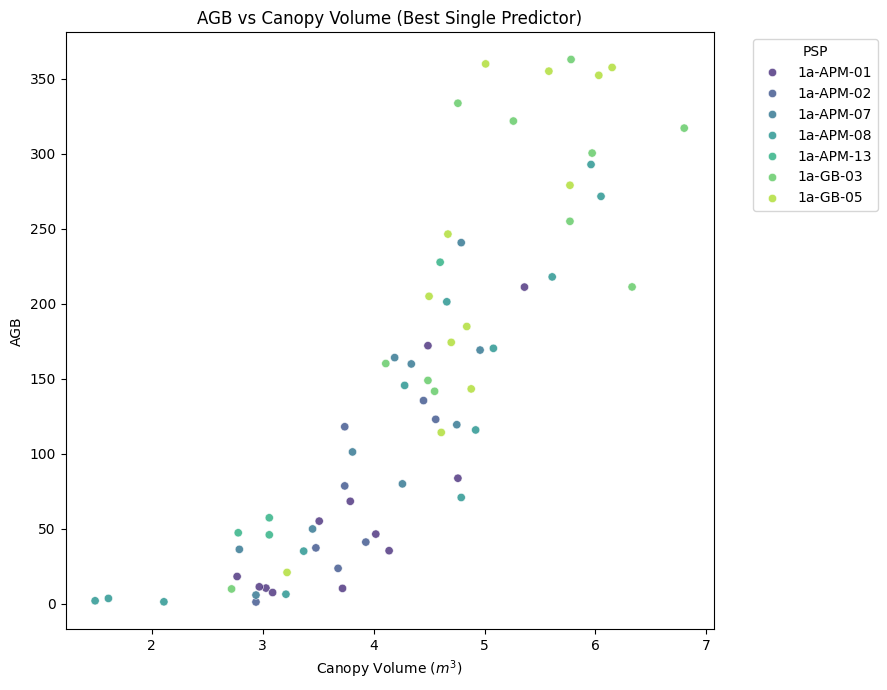

In [1859]:
#plotting agb against our best single predictor
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x='hmean', 
    y='total_agb', 
    hue='psp', 
    data=model_df, 
    palette='viridis', 
    alpha=0.8           
)

plt.xlabel('Canopy Volume ($m^3$)')
plt.ylabel('AGB')
plt.title('AGB vs Canopy Volume (Best Single Predictor)')

plt.legend(title='PSP', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  
plt.show()

In [1860]:
print(
    model_df["psp"]
    .value_counts()
    .sort_index()
)

psp
1a-APM-01    12
1a-APM-02     8
1a-APM-07    10
1a-APM-08    13
1a-APM-13     4
1a-GB-03     11
1a-GB-05     12
Name: count, dtype: int64


## 3. Group Fold splitting

Given the concept of spatial autocorrelation, and the evidence of site effect, we do not want to have plants that grow in the same plot appearing in both the training and testing samples. This will cause the model to overfit to certain psps, when in reality we want a model that can be taken from this psp into a new, completely unseen site. This is why we want to do a test that tests on a new, completely unseen psp

In [1861]:
groups = model_df["psp"]

gkf = GroupKFold(n_splits=6)

In [1862]:
fold_info = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(model_df, groups=model_df["psp"])
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    fold_info.append({
        "fold": fold,
        "test_psp": test["psp"].unique().tolist(),
        "n_train": len(train),
        "n_test": len(test),

        "train_agb_min": train["total_agb"].min(),
        "train_agb_max": train["total_agb"].max(),
        "train_agb_mean": train["total_agb"].mean(),

        "test_agb_min": test["total_agb"].min(),
        "test_agb_max": test["total_agb"].max(),
        "test_agb_mean": test["total_agb"].mean(),

        "test_agb_std": test["total_agb"].std()
    })

fold_info = pd.DataFrame(fold_info)

fold_info

,fold,test_psp,n_train,n_test,train_agb_min,train_agb_max,train_agb_mean,test_agb_min,test_agb_max,test_agb_mean,test_agb_std
0,0,[1a-APM-08],57,13,1.31,362.77,142.990351,1.43,292.78,118.100000,106.515184
1,1,[1a-GB-05],58,12,1.31,362.77,118.848276,21.01,359.82,232.712500,111.431563
2,2,[1a-APM-01],58,12,1.31,362.77,154.393103,7.63,211.12,60.912500,66.454288
3,3,[1a-GB-03],59,11,1.31,359.82,120.732712,10.00,362.77,232.956364,108.551808
4,4,[1a-APM-07],60,10,1.31,362.77,142.646667,5.94,240.73,112.695000,72.152481
5,5,"[1a-APM-02, 1a-APM-13]",58,12,1.43,362.77,150.832241,1.31,227.69,78.123333,62.923056


## 4. Model Evaluation

We create a common accuracy evaluation function to be shared by all models in this analysis

The accuracy metrics we use for evaluation:
- Mean Absolute Error (mae)
- Root Mean Square Error (rmse)
- Mean Bias Error (mbe)
- rRMSE

In [1863]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    residuals = y_true - y_pred

    sse = np.sum(residuals ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (sse / sst)

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals ** 2))

    # Relative RMSE expressed as a percentage of mean observed biomass
    rrmse = 100 * rmse / np.mean(y_true)

    # Mean bias error
    mbe = np.mean(residuals)


    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "rRMSE_percent": rrmse,
        "MBE": mbe
    }

## 5. Baseline models

The first stage establishes baseline relationships between canopy structure and biomass.

The following model forms are evaluated:

* Null model using no predictors to be used as a baseline for other model evaluation
* Simple linear model using canopy volume.
* Multiple linear model using canopy area and mean height.
* Multiple linear model using canopy volume and mean height.
* Polynomial model using canopy volume.
* Power model using canopy volume.

These models provide a reference against which additional predictors and alternative model structures can be evaluated.

####  M0: Null model
* **Feature:** This model has no features. It predicts the mean biomass for each clump, therefore creating a baseline for which each model is judged.

In [1864]:
m0_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
    
    # Mean biomass from training PSPs only
    train_mean = train["total_agb"].mean()

    y_true = test["total_agb"]
    y_pred = np.full(
        len(test),
        train_mean
    )

    fold_results = test[
        ["psp", "clump_id", "total_agb"]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M0_null"

    m0_predictions.append(fold_results)


m0_predictions = pd.concat(
    m0_predictions,
    ignore_index=True
)

##### Overall out of fold metrics

In [1865]:
m0_metrics = calculate_metrics(
    m0_predictions["total_agb"],
    m0_predictions["prediction"]
)

print("M0: Null Model")
print("-" * 40)

for metric, value in m0_metrics.items():
    print(f"{metric}: {value:.4f}")

M0: Null Model
----------------------------------------
R2: -0.1702
MAE: 102.2406
RMSE: 120.0592
rRMSE_percent: 86.7682
MBE: -0.2362


##### Per psp M0

In [1866]:
m0_by_psp = []

for psp, group in m0_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m0_by_psp.append(metrics)


m0_by_psp = pd.DataFrame(m0_by_psp)

m0_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
]

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,-2.158667,105.884569,113.078651,185.641126
1,1a-APM-02,-2.876164,80.974741,94.003457,134.564588
2,1a-APM-07,-0.191468,62.620333,74.716028,66.299328
3,1a-APM-08,-0.059156,92.822335,105.319914,89.178589
4,1a-APM-13,-0.533207,94.606121,95.260491,100.639682
5,1a-GB-03,-1.175675,132.356872,152.664391,65.533471
6,1a-GB-05,-1.139060,130.931983,156.036231,67.051074


#### M1: Simple linear model

Evaluates whether canopy volume alone can explain biomass variations

Predictor:
* Canopy volume

Model form:
* `AGB=β0​+β1​Volume` 

In [1867]:
m1_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    X_train = train[
        ['canopy_volume_m3'
               ]
    ]

    y_train = train[
        "total_agb"
    ]

    X_test = test[
        ['canopy_volume_m3'
               ]
    ]

    y_test = test[
        "total_agb"
    ]

    model = LinearRegression()

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    fold_results = test[
        ["psp", "clump_id", "total_agb"]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M1_linear"

    m1_predictions.append(
        fold_results
    )


m1_predictions = pd.concat(
    m1_predictions,
    ignore_index=True
)

In [1868]:
m1_metrics = calculate_metrics(
    m1_predictions["total_agb"],
    m1_predictions["prediction"]
)

print("M1: Linear Regression")
print("-" * 40)

for metric, value in m1_metrics.items():
    print(f"{metric}: {value:.4f}")

M1: Linear Regression
----------------------------------------
R2: 0.8642
MAE: 30.5157
RMSE: 40.8973
rRMSE_percent: 29.5569
MBE: -0.1694


##### Compare M0 and M1

In [1869]:
results_m0_m1 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        }
    ]
)

results_m0_m1

,Model,R2,MAE,RMSE,rRMSE_percent,MBE
0,M0 - Null,-0.170182,102.240576,120.059248,86.768163,-0.236207
1,M1 - Linear Volume,0.864215,30.515712,40.897250,29.556901,-0.169385


#### What are the coefficients

In [1870]:
model_m1_full = LinearRegression()

model_m1_full.fit(
    model_df[["canopy_volume_m3"]],
    model_df["total_agb"]
)

print(
    "Intercept:",
    model_m1_full.intercept_
)

print(
    "Volume coefficient:",
    model_m1_full.coef_[0]
)

Intercept: 2.3501446151619803
Volume coefficient: 1.0272609342043768


#### Observed vs predicted

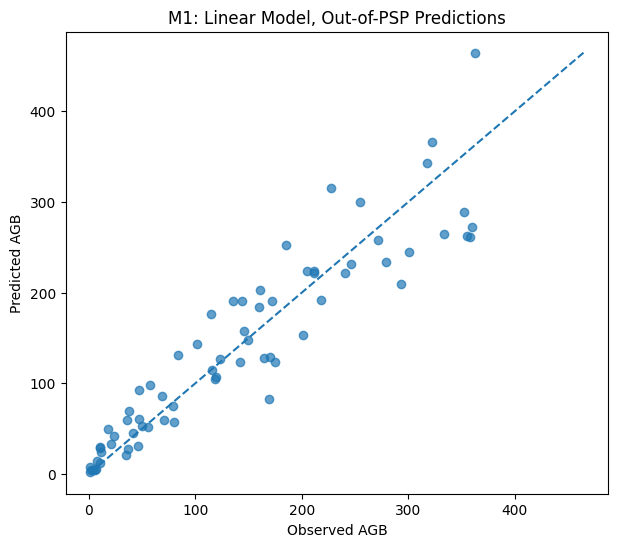

In [1871]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m1_predictions["total_agb"],
    m1_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m1_predictions["total_agb"].min(),
    m1_predictions["prediction"].min()
)

max_val = max(
    m1_predictions["total_agb"].max(),
    m1_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title("M1: Linear Model, Out-of-PSP Predictions")

plt.show()

##### Residuals

In [1872]:
m1_predictions["residual"] = (
    m1_predictions["total_agb"]
    - m1_predictions["prediction"]
)

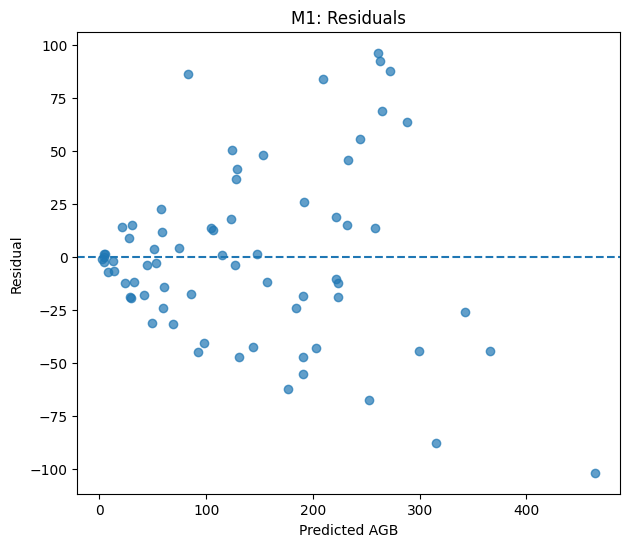

In [1873]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m1_predictions["prediction"],
    m1_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M1: Residuals")

plt.show()

#### Per psp performance

In [1874]:
m1_by_psp = []

for psp, group in m1_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m1_by_psp.append(metrics)

m1_by_psp = pd.DataFrame(m1_by_psp)

m1_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.891764,17.161827,20.932159,34.364307
1,1a-APM-02,0.745376,17.116384,24.093099,34.488923
2,1a-APM-07,0.738478,25.635390,35.004722,31.061469
3,1a-APM-08,0.908640,19.760027,30.931996,26.191360
4,1a-APM-13,0.513119,46.966460,53.681402,56.712696
5,1a-GB-03,0.784153,39.445811,48.085447,20.641397
6,1a-GB-05,0.666684,54.851901,61.594530,26.468080


#### M2A: Multiple Linear Model Area + Height

The second model evaluates whether combining canopy area with mean canopy height provides additional information compared with canopy volume alone.

Predictors:

* canopy_area
* hmean

Model form:

    total_agb ~ canopy_area + hmean


In [1875]:
m2a_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
   
    X_train = train[
        [
             'hmean', 
             'canopy_area'
        ]
    ]   
    y_train = train["total_agb"]

    X_test = test[
        [
            'hmean', 
            'canopy_area'
        ]
    ]

    y_test = test["total_agb"]

    # initialize model
    model = LinearRegression()

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Predict held-out PSP
    y_pred = model.predict(
        X_test
    )

    # Store out-of-fold predictions
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M2A_area_hmean"

    m2a_predictions.append(
        fold_results
    )


m2a_predictions = pd.concat(
    m2a_predictions,
    ignore_index=True
)

In [1876]:
#ensure no negative or zero predictions
m2a_predictions['prediction'] = m2a_predictions['prediction'].clip(lower=1)

In [1877]:
m2_metrics = calculate_metrics(
    m2a_predictions["total_agb"],
    m2a_predictions["prediction"]
)

print("M2A: Area + Mean Height")
print("-" * 40)

for metric, value in m2_metrics.items():
    print(f"{metric}: {value:.4f}")

M2A: Area + Mean Height
----------------------------------------
R2: 0.8652
MAE: 29.9852
RMSE: 40.7472
rRMSE_percent: 29.4485
MBE: -3.3035


##### M2A Performance per PSP

In [1878]:
m2a_by_psp = []

for psp, group in m2a_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m2a_by_psp.append(metrics)


m2a_by_psp = pd.DataFrame(
    m2a_by_psp
)

m2a_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.694812,26.695371,35.148972,57.704038
1,1a-APM-02,0.620541,23.966464,29.412031,42.102896
2,1a-APM-07,0.875848,21.192463,24.118484,21.401557
3,1a-APM-08,0.951302,16.757305,22.583312,19.122195
4,1a-APM-13,0.641872,42.205363,46.039617,48.639393
5,1a-GB-03,0.856693,27.260920,39.180954,16.819010
6,1a-GB-05,0.585135,57.368647,68.717478,29.528916


##### Observed vs Predicted

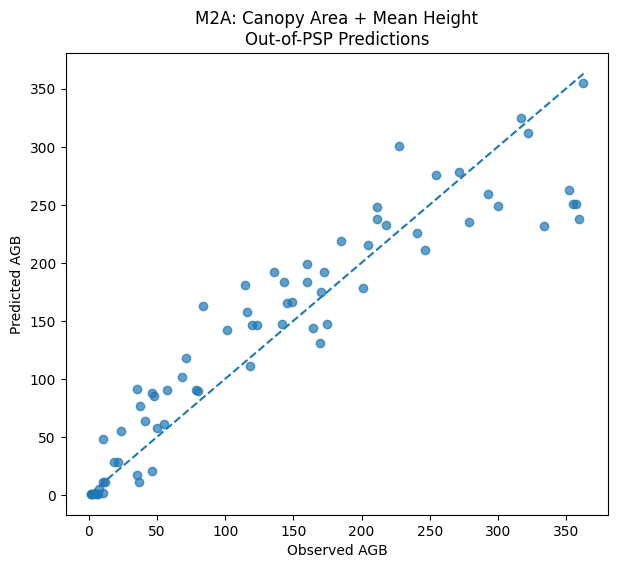

In [1879]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2a_predictions["total_agb"],
    m2a_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m2a_predictions["total_agb"].min(),
    m2a_predictions["prediction"].min()
)

max_val = max(
    m2a_predictions["total_agb"].max(),
    m2a_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M2A: Canopy Area + Mean Height\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [1880]:
m2a_predictions["residual"] = (
    m2a_predictions["total_agb"]
    - m2a_predictions["prediction"]
)

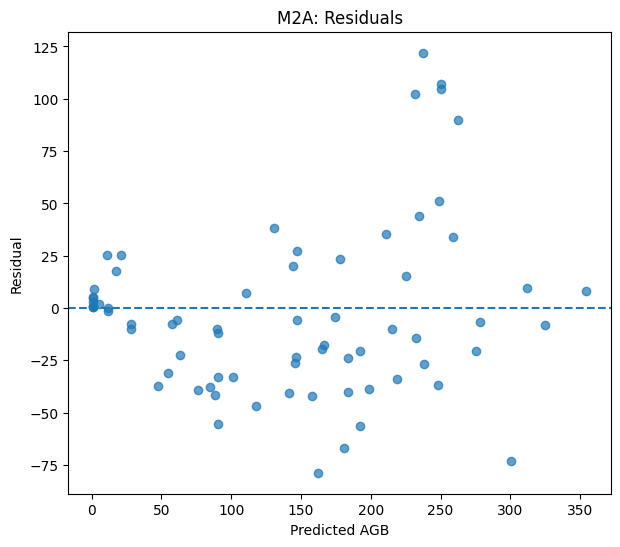

In [1881]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2a_predictions["prediction"],
    m2a_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M2A: Residuals")

plt.show()

##### Intercept

In [1882]:
# Fit M2A on all data for interpretation only

m2a_full = LinearRegression()

m2a_full.fit(
    model_df[
        [
            "canopy_area",
            "hmean"
        ]
    ],
    model_df["total_agb"]
)

print(
    "Intercept:",
    m2a_full.intercept_
)

print(
    "Canopy area coefficient:",
    m2a_full.coef_[0]
)

print(
    "Mean height coefficient:",
    m2a_full.coef_[1]
)

Intercept: -148.6777841153501
Canopy area coefficient: 4.138034588193196
Mean height coefficient: 45.123954519019854


#### M2B: Multiple Linear Model Canopy volume + Height

The second model evaluates whether combining canopy volume with mean canopy height provides additional information compared with canopy volume alone.

Predictors:

* canopy_volume
* hmean

Model form:

    total_agb ~ canopy_volume + hmean


In [1883]:
m2b_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
   
    X_train = train[
        [
             'hmean', 
             'canopy_volume_m3'
        ]
    ]   
    y_train = train["total_agb"]

    X_test = test[
        [
            'hmean', 
            'canopy_volume_m3'
        ]
    ]

    y_test = test["total_agb"]

    # initialize model
    model = LinearRegression()

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Predict held-out PSP
    y_pred = model.predict(
        X_test
    )

    # Store out-of-fold predictions
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M2B_volume_hmean"

    m2b_predictions.append(
        fold_results
    )


m2b_predictions = pd.concat(
    m2b_predictions,
    ignore_index=True
)

In [1884]:
#ensure no zero or negative predictions
m2b_predictions['prediction'] = m2b_predictions['prediction'].clip(lower=1)

In [1885]:
m2b_metrics = calculate_metrics(
    m2b_predictions["total_agb"],
    m2b_predictions["prediction"]
)

print("M2B: Volume + Mean Height")
print("-" * 40)

for metric, value in m2b_metrics.items():
    print(f"{metric}: {value:.4f}")

M2B: Volume + Mean Height
----------------------------------------
R2: 0.8945
MAE: 26.9811
RMSE: 36.0423
rRMSE_percent: 26.0482
MBE: -2.0337


#### Finding:
* Note that canopy volume and height outperforms canopy area and height, and so we take this as our best multiple linear model

In [1886]:
#so: we take the canopy volume height model as the better m2 model
m2_metrics = calculate_metrics(
    m2b_predictions["total_agb"],
    m2b_predictions["prediction"]
)

print("M2B: Volume + Mean Height")
print("-" * 40)

for metric, value in m2_metrics.items():
    print(f"{metric}: {value:.4f}")

M2B: Volume + Mean Height
----------------------------------------
R2: 0.8945
MAE: 26.9811
RMSE: 36.0423
rRMSE_percent: 26.0482
MBE: -2.0337


##### M0 M1 M2 together

In [1887]:
results_m0_m2 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Volume + Mean Height",
            **m2_metrics
        }
    ]
)

results_m0_m2

,Model,R2,MAE,RMSE,rRMSE_percent,MBE
0,M0 - Null,-0.170182,102.240576,120.059248,86.768163,-0.236207
1,M1 - Linear Volume,0.864215,30.515712,40.897250,29.556901,-0.169385
2,M2 - Volume + Mean Height,0.894540,26.981069,36.042303,26.048176,-2.033704


##### M2B performance per psp

In [1888]:
m2b_by_psp = []

for psp, group in m2b_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m2b_by_psp.append(metrics)


m2b_by_psp = pd.DataFrame(
    m2b_by_psp
)

m2b_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.812625,20.643140,27.541332,45.214582
1,1a-APM-02,0.760020,19.017093,23.389985,33.482425
2,1a-APM-07,0.852070,20.198869,26.326978,23.361266
3,1a-APM-08,0.957832,14.830364,21.014710,17.793996
4,1a-APM-13,0.808715,29.529871,33.647501,35.547515
5,1a-GB-03,0.833117,33.769579,42.281101,18.149794
6,1a-GB-05,0.702834,50.371010,58.158509,24.991571


##### Observed vs predicted

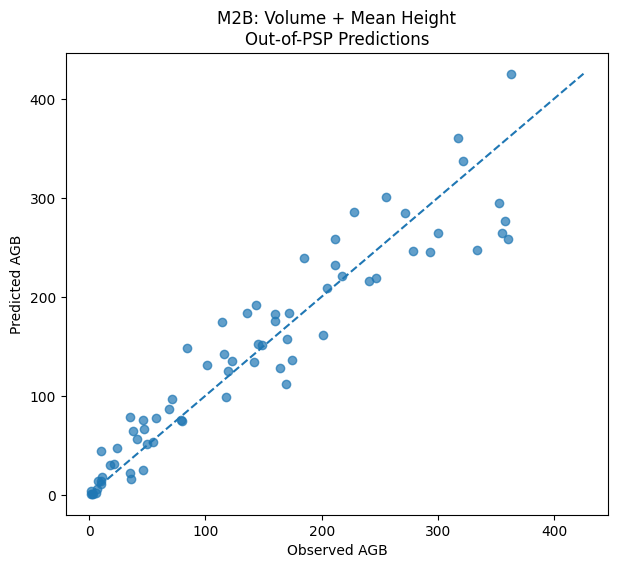

In [1889]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2b_predictions["total_agb"],
    m2b_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m2b_predictions["total_agb"].min(),
    m2b_predictions["prediction"].min()
)

max_val = max(
    m2b_predictions["total_agb"].max(),
    m2b_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M2B: Volume + Mean Height\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [1890]:
m2b_predictions["residual"] = (
    m2b_predictions["total_agb"]
    - m2b_predictions["prediction"]
)

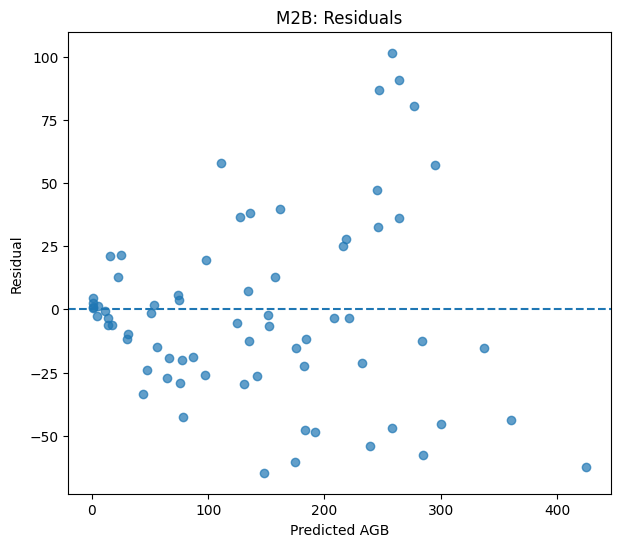

In [1891]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2b_predictions["prediction"],
    m2b_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M2B: Residuals")

plt.show()

#### Intercept

In [1892]:
# Fit M2 on all 2026 data for interpretation only

m2b_full = LinearRegression()

m2b_full.fit(
    model_df[
        [
            "canopy_volume_m3",
            "hmean"
        ]
    ],
    model_df["total_agb"]
)

print(
    "Intercept:",
    m2b_full.intercept_
)

print(
    "Canopy volume coefficient:",
    m2b_full.coef_[0]
)

print(
    "Mean height coefficient:",
    m2b_full.coef_[1]
)

Intercept: -78.97554009998075
Canopy volume coefficient: 0.782612412860262
Mean height coefficient: 26.57077965063725


#### M3A: Polynomial Model: Canopy Volume

A polynomial relationship is evaluated to determine whether the relationship between canopy volume and biomass is better represented as nonlinear.

Predictor:

- canopy_volume_m3

Model form:

    AGB ~ Volume + Volume²

The polynomial degree and implementation are specified in the corresponding code.

In [1893]:
m3a_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------

    X_train = train[
        ['canopy_volume_m3']
    ]

    y_train = train[
        "total_agb"
    ]

    # -----------------------------
    # Test data
    # -----------------------------

    X_test = test[
        ['canopy_volume_m3']
    ]

    y_test = test[
        "total_agb"
    ]

    # -----------------------------
    # Create polynomial features
    # -----------------------------

    poly_transformer = PolynomialFeatures(
        degree=2,
        include_bias=False
    )

    X_train_poly = poly_transformer.fit_transform(
        X_train
    )

    X_test_poly = poly_transformer.transform(
        X_test
    )

    # -----------------------------
    # Train polynomial regression model
    # -----------------------------

    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train
    )

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------

    y_pred = model.predict(
        X_test_poly
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred

    fold_results["model"] = "M3A_polynomial_volume"

    m3a_predictions.append(
        fold_results
    )


m3a_predictions = pd.concat(
    m3a_predictions,
    ignore_index=True
)

In [1894]:
m3a_metrics = calculate_metrics(
    m3a_predictions["total_agb"],
    m3a_predictions["prediction"]
)

print("M3A: Polynomial Volume")
print("-" * 40)

for metric, value in m3a_metrics.items():
    print(f"{metric}: {value:.4f}")

M3A: Polynomial Volume
----------------------------------------
R2: 0.8469
MAE: 32.5162
RMSE: 43.4220
rRMSE_percent: 31.3816
MBE: -1.8674


##### M3A Performance Per PSP

In [1895]:
m3a_by_psp = []

for psp, group in m2b_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m3a_by_psp.append(metrics)


m3a_by_psp = pd.DataFrame(
    m3a_by_psp
)

m3a_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.812625,20.643140,27.541332,45.214582
1,1a-APM-02,0.760020,19.017093,23.389985,33.482425
2,1a-APM-07,0.852070,20.198869,26.326978,23.361266
3,1a-APM-08,0.957832,14.830364,21.014710,17.793996
4,1a-APM-13,0.808715,29.529871,33.647501,35.547515
5,1a-GB-03,0.833117,33.769579,42.281101,18.149794
6,1a-GB-05,0.702834,50.371010,58.158509,24.991571


##### Observed vs Predicted

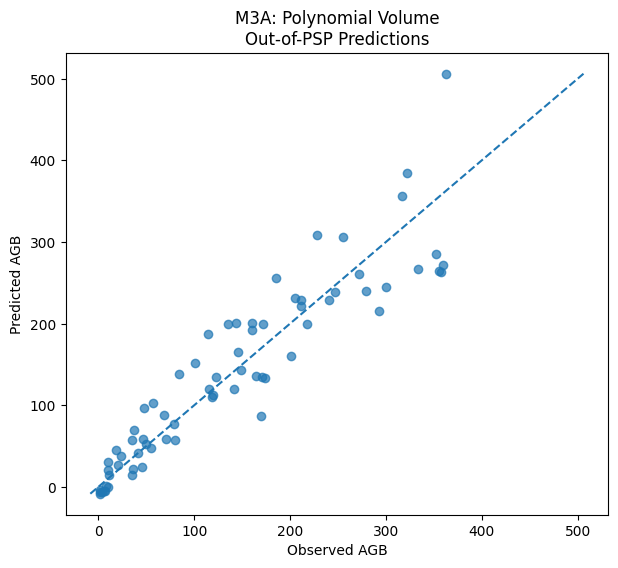

In [1896]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m3a_predictions["total_agb"],
    m3a_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m3a_predictions["total_agb"].min(),
    m3a_predictions["prediction"].min()
)

max_val = max(
    m3a_predictions["total_agb"].max(),
    m3a_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M3A: Polynomial Volume\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

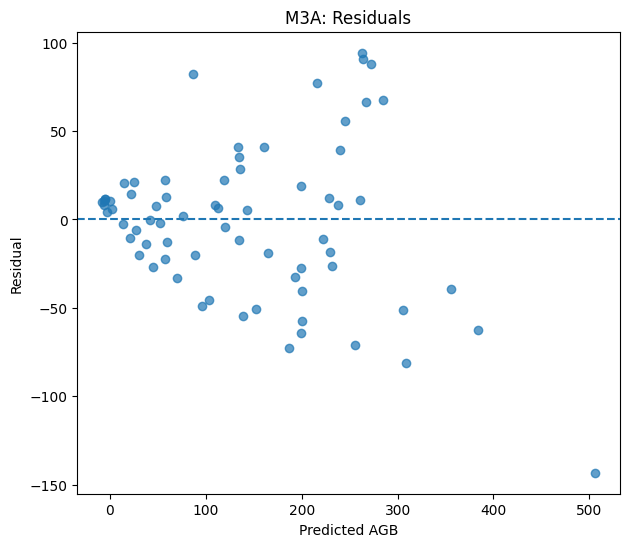

In [1897]:
m3a_predictions["residual"] = (
    m3a_predictions["total_agb"]
    - m3a_predictions["prediction"]
)
plt.figure(figsize=(7, 6))

plt.scatter(
    m3a_predictions["prediction"],
    m3a_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M3A: Residuals")

plt.show()

##### Intercept

In [1898]:
# Fit on the full dataset ONLY for examining coefficients
X = model_df[
    ["canopy_volume_m3"]
]

y = model_df[
    "total_agb"
]

poly_full = PolynomialFeatures(
    degree=1,
    include_bias=False
)

X_poly = poly_full.fit_transform(X)

m3a_full = LinearRegression()

m3a_full.fit(
    X_poly,
    y
)

print(
    "Features:",
    poly_full.get_feature_names_out(
        ["canopy_volume_m3"]
    )
)

print(
    "Coefficients:",
    m3a_full.coef_
)

print(
    "Intercept:",
    m3a_full.intercept_
)

Features: ['canopy_volume_m3']
Coefficients: [1.02726093]
Intercept: 2.3501446151619803


#### M3B: Polynomial Model with Linear passthrough: Canopy Volume + Mean Height

A polynomial relationship is evaluated to determine whether the nonlinear characteristic of relationship between canopy volume and biomass can be combined with a linear relationship with height to achieve better accuracy.

Predictors:

- canopy_volume_m3
- hmean

Model form:

    AGB ~ Volume + Volume² + Height

The polynomial degree and implementation are specified in the corresponding code.

In [1899]:
m3b_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------

    X_train = train[
        [ 'canopy_volume_m3', 'hmean'
         ]
    ]

    y_train = train[
        "total_agb"
    ]

    # -----------------------------
    # Test data
    # -----------------------------

    X_test = test[
        ['canopy_volume_m3', 'hmean'
         ]
    ]

    y_test = test[
        "total_agb"
    ]

    # -----------------------------
    # Create polynomial features
    # -----------------------------
    
    # Target only 'canopy_volume_m3' for degree 2 (no bias column needed)
    # Let 'remainder="passthrough"' keep all other features untouched
    poly_transformer = ColumnTransformer(
        transformers=[
            ('volume_poly', PolynomialFeatures(degree=2, include_bias=False), ['hmean'])
        ],
        remainder='passthrough' 
    )

    X_train_poly = poly_transformer.fit_transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # -----------------------------
    # Linear regression on
    # polynomial features
    # -----------------------------

    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train
    )

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------

    y_pred = model.predict(
        X_test_poly
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M3_polynomial_volume"

    m3b_predictions.append(
        fold_results
    )


m3b_predictions = pd.concat(
    m3b_predictions,
    ignore_index=True
)

In [1900]:
m3b_metrics = calculate_metrics(
    m3b_predictions["total_agb"],
    m3b_predictions["prediction"]
)

print("M3B: Polynomial Volume + Linear Height")
print("-" * 40)

for metric, value in m3b_metrics.items():
    print(f"{metric}: {value:.4f}")

M3B: Polynomial Volume + Linear Height
----------------------------------------
R2: 0.8689
MAE: 29.3826
RMSE: 40.1866
rRMSE_percent: 29.0433
MBE: -0.7641


#### Finding:
Polynomial volume and linear height passthrough performs better than polynomial volume only and so this is updated as m3

In [1901]:
m3_metrics = m3b_metrics

In [1902]:
results_m0_m3 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Volume + Mean Height",
            **m2_metrics
        },
        {
            "Model": "M3 - Polynomial Volume + Linear Height",
            **m3_metrics
        }
    ]
)

results_m0_m3

,Model,R2,MAE,RMSE,rRMSE_percent,MBE
0,M0 - Null,-0.170182,102.240576,120.059248,86.768163,-0.236207
1,M1 - Linear Volume,0.864215,30.515712,40.897250,29.556901,-0.169385
2,M2 - Volume + Mean Height,0.894540,26.981069,36.042303,26.048176,-2.033704
3,M3 - Polynomial Volume + Linear Height,0.868893,29.382556,40.186627,29.043326,-0.764102


In [1903]:
print(
    "M3 vs M1"
)

print(
    "R² improvement:",
    m3_metrics["R2"] - m1_metrics["R2"]
)

print(
    "MAE improvement:",
    m1_metrics["MAE"] - m3_metrics["MAE"]
)

print(
    "RMSE improvement:",
    m1_metrics["RMSE"] - m3_metrics["RMSE"]
)

print(
    "rRMSE improvement:",
    m1_metrics["rRMSE_percent"] - m3_metrics["rRMSE_percent"]
)

M3 vs M1
R² improvement: 0.004677736963551782
MAE improvement: 1.1331555080164222
RMSE improvement: 0.7106230232321238
rRMSE improvement: 0.51357521747153


In [1904]:
# Fit on the full dataset ONLY for examining coefficients

X = model_df[
    ["canopy_volume_m3"]
]

y = model_df[
    "total_agb"
]

poly_full = PolynomialFeatures(
    degree=1,
    include_bias=False
)

X_poly = poly_full.fit_transform(X)

m3_full = LinearRegression()

m3_full.fit(
    X_poly,
    y
)

print(
    "Features:",
    poly_full.get_feature_names_out(
        ["canopy_volume_m3"]
    )
)

print(
    "Coefficients:",
    m3_full.coef_
)

print(
    "Intercept:",
    m3_full.intercept_
)

Features: ['canopy_volume_m3']
Coefficients: [1.02726093]
Intercept: 2.3501446151619803


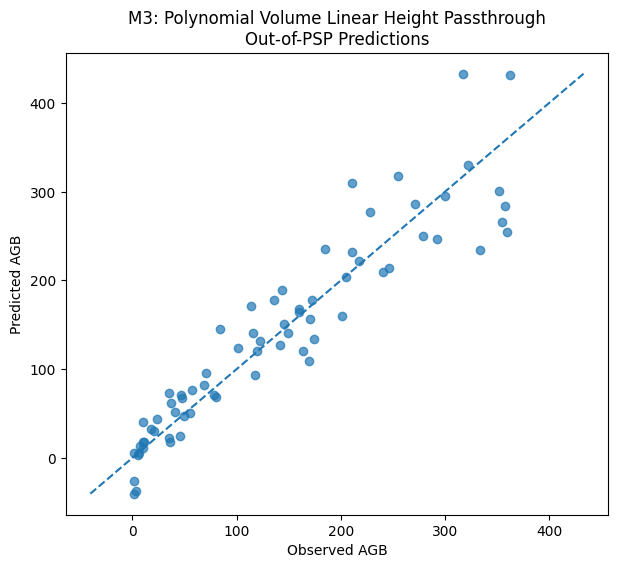

In [1905]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m3b_predictions["total_agb"],
    m3b_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m3b_predictions["total_agb"].min(),
    m3b_predictions["prediction"].min()
)

max_val = max(
    m3b_predictions["total_agb"].max(),
    m3b_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")

plt.title(
    "M3: Polynomial Volume Linear Height Passthrough\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [1906]:
m3b_predictions["residual"] = (
    m3b_predictions["total_agb"]
    - m3b_predictions["prediction"]
)

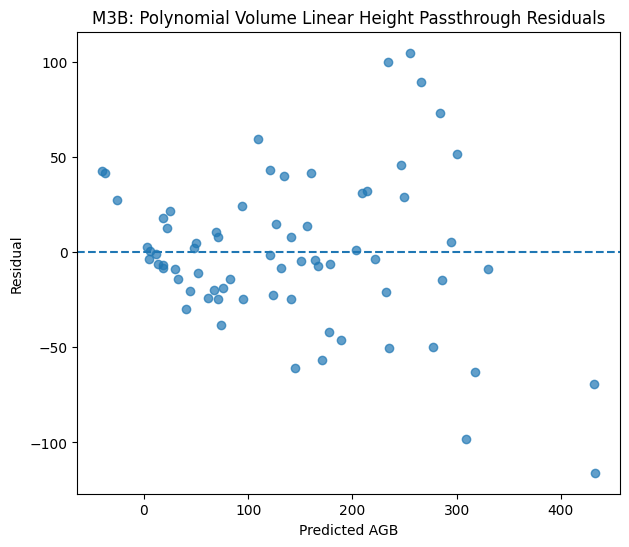

In [1907]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m3b_predictions["prediction"],
    m3b_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")

plt.title(
    "M3B: Polynomial Volume Linear Height Passthrough Residuals"
)

plt.show()

##### Per psp performance

In [1908]:
m3_by_psp = []

for psp, group in m3_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m3_by_psp.append(metrics)


m3_by_psp = pd.DataFrame(
    m3_by_psp
)

m3_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.841938,19.017557,25.295455,41.527527
1,1a-APM-02,0.801543,17.723813,21.270401,30.448271
2,1a-APM-07,0.841267,19.974830,27.271350,24.199254
3,1a-APM-08,0.927359,22.912674,27.581754,23.354576
4,1a-APM-13,0.843796,27.527561,30.405956,32.122926
5,1a-GB-03,0.641332,45.033570,61.985028,26.607999
6,1a-GB-05,0.718413,48.640431,56.613503,24.327659


In [1909]:
model_df[model_df['psp'] == '1a-APM-02'][['clump_id', 'canopy_volume_m3', 'total_agb', 'hmean']]

,clump_id,canopy_volume_m3,total_agb,hmean
37,CLUMP #4,67.53,78.65,3.74
39,CLUMP #5,3.83,1.31,2.94
41,CLUMP #6,62.36,37.37,3.48
43,CLUMP #7,35.89,23.73,3.68
45,CLUMP #8,39.13,41.22,3.93
47,CLUMP #9,179.01,135.50,4.45
49,CLUMP #10,117.73,123.01,4.56
51,CLUMP #11,96.00,118.07,3.74


#### M4: Normal Logarithm Power model

A power relationship is evaluated because biomass may scale nonlinearly with canopy volume.

Predictor:
    
    canopy_volume_m3

Model form:

    log(AGB) ~ log(canopy_volume_m3)

In [1910]:
print("Minimum AGB:", model_df["total_agb"].min())
print("Minimum volume:", model_df["canopy_volume_m3"].min())

Minimum AGB: 1.31
Minimum volume: 1.87


In [1911]:
m4_predictions = []


features_to_use = [
   'canopy_volume_m3'
]

# Custom function safe transform the values excluding zero values, if present
def safe_log1p(X):
    return np.log1p(np.clip(X, a_min=0, a_max=None))

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):
    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Data splitting
    # -----------------------------
    X_train = train[features_to_use]
    X_test = test[features_to_use]
    
    # Target log transformation (safe from 0 values)
    y_train = np.log1p(train["total_agb"])
    
    # -----------------------------
    # Log transform features
    # -----------------------------
    log_transformer = ColumnTransformer(
        transformers=[
            ('log_transform', FunctionTransformer(safe_log1p), ['canopy_volume_m3'])
        ],
        remainder='passthrough'
    )

    # Use .values to ensure smooth evaluation with the custom function
    X_train_log = log_transformer.fit_transform(X_train)
    X_test_log = log_transformer.transform(X_test)

    # -----------------------------
    # Fit log-log linear model
    # -----------------------------
    model = LinearRegression()
    model.fit(
        X_train_log,
        y_train
    )

    # -----------------------------
    # Predict and transform back
    # -----------------------------
    log_pred = model.predict(X_test_log)
    
    # Convert predictions back to original AGB scale safely
    y_pred = np.expm1(log_pred)

    # -----------------------------
    # Store predictions
    # -----------------------------
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M4_power_volume"

    m4_predictions.append(fold_results)

m4_predictions = pd.concat(
    m4_predictions,
    ignore_index=True
)

In [1912]:
m4_metrics = calculate_metrics(
    m4_predictions["total_agb"],
    m4_predictions["prediction"]
)

print("M4: Power Volume")
print("-" * 40)

for metric, value in m4_metrics.items():
    print(f"{metric}: {value:.4f}")

M4: Power Volume
----------------------------------------
R2: 0.8686
MAE: 29.5405
RMSE: 40.2240
rRMSE_percent: 29.0704
MBE: 5.3954


In [1913]:
results_m0_m4 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Area + Mean Height",
            **m2_metrics
        },
        {
            "Model": "M3 - Polynomial Volume",
            **m3_metrics
        },
        {
            "Model": "M4 - Power Volume",
            **m4_metrics
        }
    ]
)

results_m0_m4

,Model,R2,MAE,RMSE,rRMSE_percent,MBE
0,M0 - Null,-0.170182,102.240576,120.059248,86.768163,-0.236207
1,M1 - Linear Volume,0.864215,30.515712,40.897250,29.556901,-0.169385
2,M2 - Area + Mean Height,0.894540,26.981069,36.042303,26.048176,-2.033704
3,M3 - Polynomial Volume,0.868893,29.382556,40.186627,29.043326,-0.764102
4,M4 - Power Volume,0.868649,29.540521,40.224027,29.070355,5.395449


In [1914]:
# ---------------------------------------
# Full-data power model
# Interpretation only
# ---------------------------------------

X_full = np.log(
    model_df[["canopy_volume_m3"]]
)

y_full = np.log(
    model_df["total_agb"]
)

power_full = LinearRegression()

power_full.fit(
    X_full,
    y_full
)

alpha = power_full.intercept_
b = power_full.coef_[0]

a = np.exp(alpha)

print("a =", a)
print("b =", b)

print(
    f"AGB = {a:.4f} × Volume^{b:.4f}"
)

a = 0.8090660271856203
b = 1.0425906815673
AGB = 0.8091 × Volume^1.0426


### M5: Weighted Log Linear Power Model

In [1915]:
# ---------------------------------------
# MW4: WEIGHTED POWER / LOG-LOG MODEL
# ---------------------------------------

weighted_power_predictions = []

features_to_use = [
    "canopy_volume_m3", 'hmean'
]

target_col = "total_agb"

# Feature columns that will be log-transformed
log_features = 'canopy_volume_m3'

# Column used to calculate the observation weights.
# This is the closest equivalent to the paper's log(D)-based weighting.
weight_feature = "hmean"

In [1916]:
def safe_log(X, columns=None):
    """
    Apply natural logarithm while checking for invalid values.

    Parameters
    ----------
    X : pandas DataFrame or numpy array
        Input values.
    columns : list, optional
        Column names used for clearer error reporting.

    Returns
    -------
    numpy.ndarraya
        Log-transformed values.
    """

    X_array = np.asarray(X, dtype=float)

    if np.any(~np.isfinite(X_array)):
        raise ValueError("Input contains NaN or infinite values.")

    if np.any(X_array <= 0):
        invalid_count = np.sum(X_array <= 0)

        raise ValueError(
            f"Log transformation encountered {invalid_count} "
            "zero or negative values."
        )

    return np.log(X_array)

In [1917]:
check_cols = features_to_use + [target_col]

print(
    model_df[check_cols]
    .describe()
    .T
)

print("\nNon-positive values:")
print(
    (model_df[check_cols] <= 0)
    .sum()
)

                  count        mean         std   min      25%     50%  \
canopy_volume_m3   70.0  132.408143  102.123922  1.87  42.1525  119.45   
hmean              70.0    4.279857    1.143199  1.49   3.4575    4.47   
total_agb          70.0  138.367857  111.787558  1.31  38.3325  121.22   

                       75%     max  
canopy_volume_m3  211.1000  431.76  
hmean               4.9100    6.80  
total_agb         211.1875  362.77  

Non-positive values:
canopy_volume_m3    0
hmean               0
total_agb           0
dtype: int64


In [1918]:
# ---------------------------------------
# GroupKFold by PSP
# ---------------------------------------

gkf = GroupKFold(n_splits=6)

for fold_number, (train_idx, test_idx) in enumerate(
    gkf.split(
        model_df,
        groups=groups
    ),
    start=1
):

    train = model_df.iloc[train_idx].copy()
    test = model_df.iloc[test_idx].copy()

    # ---------------------------------------
    # Data splitting
    # ---------------------------------------

    X_train = train[features_to_use].copy()
    X_test = test[features_to_use].copy()

    y_train = train[target_col].to_numpy(dtype=float)
    y_test = test[target_col].to_numpy(dtype=float)

    # ---------------------------------------
    # Log-transform predictors and target
    # ---------------------------------------

    X_train_log = safe_log(
        X_train,
        columns=log_features
    )

    X_test_log = safe_log(
        X_test,
        columns=log_features
    )

    y_train_log = safe_log(y_train)

    # ---------------------------------------
    # Calculate weights
    # ---------------------------------------
    # Paper:
    # weights = 1 / log(D)^2
    #
    # Here:
    # weights = 1 / log(canopy_volume_m3)^2
    #
    # Weights are calculated from training data only.
    # ---------------------------------------

    log_weight_variable = np.log(
        train[weight_feature].to_numpy(dtype=float)
    )

    if np.any(~np.isfinite(log_weight_variable)):
        raise ValueError(
            f"Invalid log values encountered in fold {fold_number}."
        )

    if np.any(np.isclose(log_weight_variable, 0)):
        raise ValueError(
            f"One or more weights are unstable in fold {fold_number}: "
            f"log({weight_feature}) is close to zero."
        )

    sample_weights = 1 / (log_weight_variable ** 2)

    # ---------------------------------------
    # Optional weight diagnostics
    # ---------------------------------------

    print(f"\nFold {fold_number} weight diagnostics")
    print("-" * 40)
    print(f"Minimum weight: {sample_weights.min():.6f}")
    print(f"Maximum weight: {sample_weights.max():.6f}")
    print(f"Median weight:  {np.median(sample_weights):.6f}")

    # ---------------------------------------
    # Fit weighted log-log linear model
    # ---------------------------------------

    model = LinearRegression()

    model.fit(
        X_train_log,
        y_train_log,
        sample_weight=sample_weights
    )

    # ---------------------------------------
    # Training residuals on log scale
    # ---------------------------------------

    train_log_pred = model.predict(X_train_log)
    train_log_residuals = y_train_log - train_log_pred

    n_train = len(y_train_log)
    n_parameters = X_train_log.shape[1] + 1  # predictors + intercept

    residual_degrees_of_freedom = n_train - n_parameters

    if residual_degrees_of_freedom <= 0:
        raise ValueError(
            f"Insufficient residual degrees of freedom in fold "
            f"{fold_number}."
        )

    # Weighted residual variance.
    #
    # This is the closest equivalent to the residual scale used
    # by weighted lm() in R.
    weighted_sse = np.sum(
        sample_weights * train_log_residuals ** 2
    )

    sigma_squared = (
        weighted_sse / residual_degrees_of_freedom
    )

    sigma = np.sqrt(sigma_squared)

    # ---------------------------------------
    # Lognormal retransformation correction
    # ---------------------------------------
    #
    # CF = exp(RSE^2 / 2)
    # ---------------------------------------

    correction_factor = np.exp(sigma_squared / 2)

    # ---------------------------------------
    # Predict on test data
    # ---------------------------------------

    test_log_pred = model.predict(X_test_log)

    # Standard log-log back-transformation:
    # exp(predicted log AGB)
    #
    # Bias-corrected:
    # exp(predicted log AGB) * CF
    # ---------------------------------------

    y_pred = np.exp(test_log_pred) * correction_factor

    # ---------------------------------------
    # Store predictions
    # ---------------------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            target_col
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["fold"] = fold_number
    fold_results["correction_factor"] = correction_factor
    fold_results["sigma_squared_log"] = sigma_squared
    fold_results["model"] = "MW4_weighted_power"

    weighted_power_predictions.append(fold_results)


Fold 1 weight diagnostics
----------------------------------------
Minimum weight: 0.272139
Maximum weight: 0.998737
Median weight:  0.448679

Fold 2 weight diagnostics
----------------------------------------
Minimum weight: 0.272139
Maximum weight: 6.288423
Median weight:  0.491314

Fold 3 weight diagnostics
----------------------------------------
Minimum weight: 0.272139
Maximum weight: 6.288423
Median weight:  0.434984

Fold 4 weight diagnostics
----------------------------------------
Minimum weight: 0.303076
Maximum weight: 6.288423
Median weight:  0.476104

Fold 5 weight diagnostics
----------------------------------------
Minimum weight: 0.272139
Maximum weight: 6.288423
Median weight:  0.442693

Fold 6 weight diagnostics
----------------------------------------
Minimum weight: 0.272139
Maximum weight: 6.288423
Median weight:  0.431896


In [1919]:
weighted_power_predictions = pd.concat(
    weighted_power_predictions,
    ignore_index=True
)

weighted_power_metrics = calculate_metrics(
    weighted_power_predictions[target_col],
    weighted_power_predictions["prediction"]
)

print("\nMW4: Weighted Power Model")
print("-" * 40)

for metric, value in weighted_power_metrics.items():
    print(f"{metric}: {value:.4f}")


MW4: Weighted Power Model
----------------------------------------
R2: 0.8964
MAE: 25.8064
RMSE: 35.7167
rRMSE_percent: 25.8129
MBE: -1.4609


##### Site specific

In [1920]:
m4_by_psp = []

for psp, group in m4_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m4_by_psp.append(metrics)


m4_by_psp = pd.DataFrame(
    m4_by_psp
)

m4_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.932916,12.976517,16.479279,27.054018
1,1a-APM-02,0.792546,15.589038,21.747216,31.130825
2,1a-APM-07,0.701855,27.659555,37.375457,33.165142
3,1a-APM-08,0.883010,23.125426,35.002907,29.638363
4,1a-APM-13,0.567647,44.466766,50.586146,53.442656
5,1a-GB-03,0.811115,35.505536,44.982077,19.309229
6,1a-GB-05,0.679137,53.479325,60.432984,25.968946


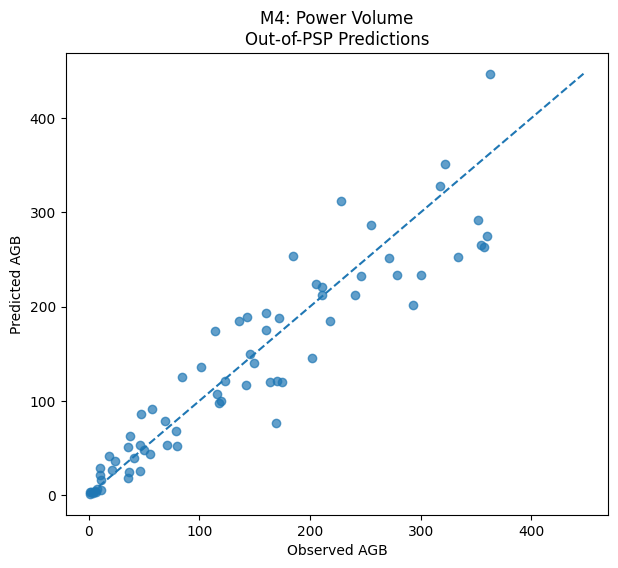

In [1921]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m4_predictions["total_agb"],
    m4_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m4_predictions["total_agb"].min(),
    m4_predictions["prediction"].min()
)

max_val = max(
    m4_predictions["total_agb"].max(),
    m4_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M4: Power Volume\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [1922]:
m4_predictions["residual"] = (
    m4_predictions["total_agb"]
    - m4_predictions["prediction"]
)

##### Biomass across levels

In [1923]:
m4_predictions["biomass_bin"] = pd.qcut(
    m4_predictions["total_agb"],
    q=4,
    duplicates="drop"
)

m4_bias_by_bin = (
    m4_predictions
    .groupby(
        "biomass_bin",
        observed=True
    )
    .agg(
        observed_mean=("total_agb", "mean"),
        predicted_mean=("prediction", "mean"),
        mean_residual=("residual", "mean"),
        MAE=(
            "residual",
            lambda x: np.mean(np.abs(x))
        ),
        n=("residual", "size")
    )
)

m4_bias_by_bin

,observed_mean,predicted_mean,mean_residual,MAE,n
biomass_bin,,,,,
"(1.3090000000000002, 38.332]",15.470556,19.694611,-4.224055,8.851371,18
"(38.332, 121.22]",76.156471,81.036602,-4.880131,21.442374,17
"(121.22, 211.188]",165.317059,161.151646,4.165413,34.894950,17
"(211.188, 362.77]",294.568333,268.686965,25.881368,52.820960,18


#### M6: Weighted Log Non Linear Power Model

In [1924]:
# ---------------------------------------
# M6: WEIGHTED NONLINEAR POWER MODEL
# ---------------------------------------
from scipy.optimize import minimize
weighted_nonlinear_predictions = []

predictor = "canopy_volume_m3"
target_col = "total_agb"


# ---------------------------------------
# Nonlinear power model
# ---------------------------------------

def power_model(params, x):
    """
    AGB = alpha * D^beta

    Parameters
    ----------
    params : array-like
        [log_alpha, beta]
    x : array-like
        Predictor D.

    Returns
    -------
    np.ndarray
        Predicted AGB.
    """

    log_alpha, beta = params

    alpha = np.exp(log_alpha)

    return alpha * np.power(x, beta)


# ---------------------------------------
# Starting values
# ---------------------------------------

def get_power_start(x, y):
    """
    Obtain starting values from log-log linear regression.
    """

    log_x = np.log(x)
    log_y = np.log(y)

    beta, intercept = np.polyfit(log_x, log_y, 1)

    log_alpha = intercept

    return np.array([log_alpha, beta])


# ---------------------------------------
# Maximum likelihood objective
# ---------------------------------------

def negative_log_likelihood(params, x, y):
    """
    Gaussian maximum likelihood objective for:

        AGB = alpha * D^beta

        sigma_i = sigma * D^k

    Parameters
    ----------
    params : array-like
        [log_alpha, beta, k, log_sigma]
    """

    log_alpha, beta, k, log_sigma = params

    alpha = np.exp(log_alpha)
    sigma = np.exp(log_sigma)

    fitted = alpha * np.power(x, beta)

    residuals = y - fitted

    sigma_i = sigma * np.power(x, k)

    standardized_residuals = residuals / sigma_i

    n = len(y)

    # Negative log likelihood, ignoring constant n*log(2*pi)/2
    nll = (
        n * np.log(sigma)
        + k * np.sum(np.log(x))
        + 0.5 * np.sum(standardized_residuals ** 2)
    )

    return nll


# ---------------------------------------
# Fit nonlinear weighted power model
# ---------------------------------------

def fit_weighted_nonlinear_power(x, y):
    """
    Fit:

        AGB = alpha * D^beta

    with variance:

        Var(e_i) proportional to D^(2k)

    using maximum likelihood.
    """

    # Starting values for alpha and beta
    power_start = get_power_start(x, y)

    log_alpha_start = power_start[0]
    beta_start = power_start[1]

    # Initial residuals
    initial_pred = power_model(
        [log_alpha_start, beta_start],
        x
    )

    initial_residuals = y - initial_pred

    # Initial sigma estimate
    sigma_start = np.std(initial_residuals)

    if sigma_start <= 0:
        sigma_start = 1.0

    initial_params = np.array([
        log_alpha_start,
        beta_start,
        0.0,                    # initial k
        np.log(sigma_start)
    ])

    result = minimize(
        negative_log_likelihood,
        initial_params,
        args=(x, y),
        method="L-BFGS-B"
    )

    if not result.success:
        raise RuntimeError(
            f"Nonlinear optimization failed: {result.message}"
        )

    log_alpha, beta, k, log_sigma = result.x

    alpha = np.exp(log_alpha)
    sigma = np.exp(log_sigma)

    return {
        "alpha": alpha,
        "beta": beta,
        "k": k,
        "sigma": sigma,
        "result": result
    }

In [1925]:
# ---------------------------------------
# GroupKFold by PSP
# ---------------------------------------

gkf = GroupKFold(n_splits=6)

for fold_number, (train_idx, test_idx) in enumerate(
    gkf.split(
        model_df,
        groups=groups
    ),
    start=1
):

    train = model_df.iloc[train_idx].copy()
    test = model_df.iloc[test_idx].copy()

    # ---------------------------------------
    # Training data
    # ---------------------------------------

    x_train = train[predictor].to_numpy(dtype=float)
    y_train = train[target_col].to_numpy(dtype=float)

    x_test = test[predictor].to_numpy(dtype=float)
    y_test = test[target_col].to_numpy(dtype=float)

    # ---------------------------------------
    # Validate values
    # ---------------------------------------

    if np.any(~np.isfinite(x_train)) or np.any(x_train <= 0):
        raise ValueError(
            f"Invalid {predictor} values in training fold {fold_number}."
        )

    if np.any(~np.isfinite(y_train)) or np.any(y_train <= 0):
        raise ValueError(
            f"Invalid {target_col} values in training fold {fold_number}."
        )

    if np.any(~np.isfinite(x_test)) or np.any(x_test <= 0):
        raise ValueError(
            f"Invalid {predictor} values in test fold {fold_number}."
        )

    # ---------------------------------------
    # Fit nonlinear model
    # ---------------------------------------

    fitted_model = fit_weighted_nonlinear_power(
        x_train,
        y_train
    )

    alpha = fitted_model["alpha"]
    beta = fitted_model["beta"]
    k = fitted_model["k"]
    sigma = fitted_model["sigma"]

    # ---------------------------------------
    # Predictions
    # ---------------------------------------

    y_pred = (
        alpha
        * np.power(x_test, beta)
    )

    # ---------------------------------------
    # Training fitted values
    # ---------------------------------------

    train_fitted = (
        alpha
        * np.power(x_train, beta)
    )

    train_residuals = y_train - train_fitted

    # ---------------------------------------
    # Weighted residuals
    #
    # Paper:
    #
    # residual / D^k
    # ---------------------------------------

    train_weighted_residuals = (
        train_residuals
        / np.power(x_train, k)
    )

    # ---------------------------------------
    # Store predictions
    # ---------------------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            target_col
        ]
    ].copy()

    fold_results["prediction"] = y_pred

    fold_results["fold"] = fold_number

    fold_results["model"] = (
        "MW5_weighted_nonlinear_power"
    )

    fold_results["alpha"] = alpha
    fold_results["beta"] = beta
    fold_results["k"] = k
    fold_results["sigma"] = sigma

    weighted_nonlinear_predictions.append(
        fold_results
    )

    # ---------------------------------------
    # Fold diagnostics
    # ---------------------------------------

    print(
        f"\nFold {fold_number}"
    )

    print("-" * 40)

    print(
        f"alpha: {alpha:.6f}"
    )

    print(
        f"beta:  {beta:.6f}"
    )

    print(
        f"k:     {k:.6f}"
    )

    print(
        f"sigma: {sigma:.6f}"
    )

    print(
        f"Weighted residual SD: "
        f"{np.std(train_weighted_residuals):.6f}"
    )


Fold 1
----------------------------------------
alpha: 0.909182
beta:  1.022091
k:     0.700343
sigma: 1.232739
Weighted residual SD: 1.232739

Fold 2
----------------------------------------
alpha: 1.069508
beta:  0.992275
k:     0.738440
sigma: 0.990444
Weighted residual SD: 0.990438

Fold 3
----------------------------------------
alpha: 1.096229
beta:  0.994720
k:     0.773407
sigma: 0.870243
Weighted residual SD: 0.870231

Fold 4
----------------------------------------
alpha: 0.997010
beta:  1.011242
k:     0.805659
sigma: 0.772677
Weighted residual SD: 0.772675

Fold 5
----------------------------------------
alpha: 0.848305
beta:  1.037276
k:     0.747308
sigma: 0.914267
Weighted residual SD: 0.914261

Fold 6
----------------------------------------
alpha: 1.043007
beta:  1.005335
k:     0.768184
sigma: 0.863337
Weighted residual SD: 0.863338


In [1926]:
weighted_nonlinear_predictions_df = pd.concat(
    weighted_nonlinear_predictions,
    ignore_index=True
)

weighted_nonlinear_predictions_df.head()

,psp,clump_id,total_agb,prediction,fold,model,alpha,beta,k,sigma
0,1a-APM-08,CLUMP #1,145.61,156.742569,1,MW5_weighted_nonlinear_power,0.909182,1.022091,0.700343,1.232739
1,1a-APM-08,CLUMP #2,70.94,57.223841,1,MW5_weighted_nonlinear_power,0.909182,1.022091,0.700343,1.232739
2,1a-APM-08,CLUMP #4,217.90,192.106608,1,MW5_weighted_nonlinear_power,0.909182,1.022091,0.700343,1.232739
3,1a-APM-08,CLUMP #5,292.78,209.712750,1,MW5_weighted_nonlinear_power,0.909182,1.022091,0.700343,1.232739
4,1a-APM-08,CLUMP #6,201.32,152.381460,1,MW5_weighted_nonlinear_power,0.909182,1.022091,0.700343,1.232739


In [1927]:
def calculate_metrics(df, target_col="total_agb"):

    observed = df[target_col].to_numpy(dtype=float)
    predicted = df["prediction"].to_numpy(dtype=float)

    residuals = observed - predicted

    r2 = (
        1
        - np.sum(residuals ** 2)
        / np.sum((observed - np.mean(observed)) ** 2)
    )

    mae = np.mean(
        np.abs(residuals)
    )

    rmse = np.sqrt(
        np.mean(residuals ** 2)
    )

    rrmse = (
        rmse
        / np.mean(observed)
        * 100
    )

    bias = np.mean(residuals)

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "rRMSE": rrmse,
        "Bias": bias
    }


mw5_metrics = calculate_metrics(
    weighted_nonlinear_predictions_df
)

mw5_metrics

{'R2': np.float64(0.8687726435528773),
 'MAE': np.float64(29.79159690226168),
 'RMSE': np.float64(40.20510336197846),
 'rRMSE': np.float64(29.056678474444336),
 'Bias': np.float64(0.362835814457877)}

#### M7: Random Forest

In [1931]:
# ---------------------------------------
# M5: tree based
# ---------------------------------------

m5_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------

    X_train = train[
        ['canopy_volume_m3', 'hmean']
    ]

    y_train = train[
        "total_agb"
    ]

    # -----------------------------
    # Test data
    # -----------------------------

    X_test = test[
        ['canopy_volume_m3', 'hmean']
    ]

    y_test = test[
        "total_agb"
    ]


    # -----------------------------
    # Random forest regression
    # -----------------------------

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------

    y_pred = model.predict(
        X_test
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M5_random_forest"

    m5_predictions.append(
        fold_results
    )


m5_predictions = pd.concat(
    m5_predictions,
    ignore_index=True
)

In [1932]:
m5_metrics = calculate_metrics(
    m5_predictions["total_agb"],
    m5_predictions["prediction"]
)

print("M5: Random Forest")
print("-" * 40)

for metric, value in m5_metrics.items():
    print(f"{metric}: {value:.4f}")

KeyError: "None of [Index([ 139.1832192724869, 117.44574007936515, 190.51461783068777,\n       254.12104665343907,  142.1405159656085, 144.81654484126986,\n       172.72223342592596,  12.56363288359788, 15.384885939153435,\n        21.39873654761904,  12.56363288359788,  12.56363288359788,\n       311.84149055555565,  257.8973615608465, 191.67105433862454,\n        278.2539373280421,  281.6669900264549,  271.7646651058199,\n       29.643389404761916, 232.85614224867726, 251.83279335978824,\n        259.0042304232803, 288.41391197089945, 172.02054310846574,\n        133.9096186640212,  146.4421415873015, 56.156057777777754,\n       30.140202539682534, 14.678958157768157, 162.38326951058207,\n        15.15131482443483,  83.12138396825402,  86.99485760582003,\n        72.33887022486773,  37.03452682539678, 26.210484126984117,\n       266.57413611111105, 151.16016117724863, 218.62676900793633,\n       327.73827165343914, 274.24025645502627, 279.80547701058197,\n       323.89879554232795,  

#### Predicting the total culms for use in prediction

In [ ]:
model_df.columns
# 1. Initialize standard KFold instead of GroupKFold
# Shuffle=True ensures random distribution of rows across folds
kf = KFold(n_splits=6, shuffle=True, random_state=42) 

m3_predictions_culms = []

# 2. Remove the groups argument from the split method
for train_idx, test_idx in kf.split(model_df):
    culms_df = model_df.copy()
    culms_df = culms_df.loc[culms_df['total_culms'] != 0]
    train = culms_df.iloc[train_idx] 
    test = culms_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------
    X_train = train[
        ['hmean', 'breast_height_perimeter_m', 'breast_height_valid_points']
    ]
    y_train = train["total_culms"]

    # -----------------------------
    # Test data
    # -----------------------------
    X_test = test[
        ['hmean', 'breast_height_perimeter_m', 'breast_height_valid_points']
    ]
    y_test = test["total_culms"]

    # -----------------------------
    # Create polynomial features
    # -----------------------------
    poly_transformer = ColumnTransformer(
        transformers=[
            ('volume_poly', PolynomialFeatures(degree=2, include_bias=False), ['breast_height_perimeter_m'])
        ],
        remainder='passthrough' 
    )

    X_train_poly = poly_transformer.fit_transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # -----------------------------
    # Linear regression on polynomial features
    # -----------------------------
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------
    y_pred = model.predict(X_test_poly)

    # -----------------------------
    # Store predictions
    # -----------------------------
    fold_results = test[
        [
            "psp", "clump_id", "total_agb", 'total_culms',
            'breast_height_valid_points', 'breast_height_points',
            'breast_height_perimeter_m', 'breast_height_diameter',
            'breast_height_area', 'bh_outside_area_m2', 'hmean',
            'canopy_volume_m3', 'canopy_area'
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M3_polynomial_volume"

    m3_predictions_culms.append(fold_results)

m3_predictions_culms = pd.concat(
    m3_predictions_culms,
    ignore_index=True
)
m3_predictions_culms['prediction'] = round(m3_predictions_culms['prediction'])



m3_culms_metrics = calculate_metrics(
    m3_predictions_culms['total_culms'],
    m3_predictions_culms['prediction']
)
print("Culms prediction")
print('-'*41)
for metric, value in m3_culms_metrics.items():
    print(f'{metric}:{value:.4f}')

Culms prediction
-----------------------------------------
R2:0.6367
MAE:9.7429
RMSE:12.1585
rRMSE_percent:33.2848
MBE:-0.0286
